In [1]:
import tensorflow as tf

In [4]:
x = tf.range(0, 100, 2)
x

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32,
       34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64, 66,
       68, 70, 72, 74, 76, 78, 80, 82, 84, 86, 88, 90, 92, 94, 96, 98],
      dtype=int32)>

In [5]:
y = 2*x + 3
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([  3,   7,  11,  15,  19,  23,  27,  31,  35,  39,  43,  47,  51,
        55,  59,  63,  67,  71,  75,  79,  83,  87,  91,  95,  99, 103,
       107, 111, 115, 119, 123, 127, 131, 135, 139, 143, 147, 151, 155,
       159, 163, 167, 171, 175, 179, 183, 187, 191, 195, 199], dtype=int32)>

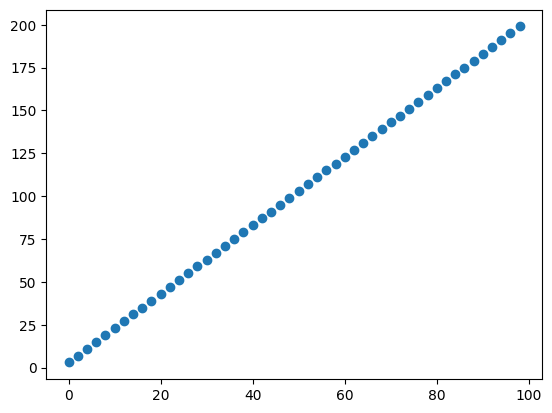

In [6]:
import matplotlib.pyplot as plt
plt.scatter(x, y)
plt.show()

## model building

In [7]:
# create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=(1,)),
    tf.keras.layers.Dense(1)
])

# compile the model
model.compile(loss = tf.keras.losses.mae,
             optimizer = tf.keras.optimizers.Adam(0.01),
             metrics = ['mae'])

# train the model
model.fit(X, y, epochs=50)

Epoch 1/50


C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 132.5364 - mae: 132.5364 
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 125.1805 - mae: 125.1805
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 118.0963 - mae: 118.0963
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 111.2806 - mae: 111.2806
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 104.5902 - mae: 104.5902
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 98.0715 - mae: 98.0715  
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 91.6574 - mae: 91.6574
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 85.3787 - mae: 85.3787
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 79.0383 - mae: 79.0383
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 72.7312 - mae: 72.7312
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 66.4038 - mae: 66.4038
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 60.2897 - mae: 60.2897
Epoch 13/50
2/2 ━━━━━━━━━━━━━━━━━━━

In [13]:
import numpy as np

# Example: predicting for one sample with 2 features
model.predict(np.array([[150]], dtype=np.float32))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


array([[305.31915]], dtype=float32)

In [14]:
x=150
y=2*x+3
y

303

## saving model

method 1

In [19]:
model.save("new_model_1.keras")


In [20]:
model.export("new_model_1")


INFO:tensorflow:Assets written to: new_model_1\assets


INFO:tensorflow:Assets written to: new_model_1\assets


Saved artifact at 'new_model_1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  1674884009040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1674884006736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1674884010384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1674884008272: TensorSpec(shape=(), dtype=tf.resource, name=None)


method 2

In [21]:
model.save("new_model_2.h5")

## Loading the saved model

In [23]:
import tensorflow as tf
new_model_1 = tf.keras.models.load_model('new_model_1.keras')

In [24]:
new_model_1.predict(np.array([[150]], dtype=np.float32))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


array([[305.31915]], dtype=float32)